In [167]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from package.RankAMIP.logistic import run_logistic_regression
from package.RankAMIP.data_script import make_BT_design_matrix
from package.RankAMIP.logistic import LogisticAMIP
from package.RankAMIP.logistic import find_closest_matchups
from package.RankAMIP.logistic import isRankingRobust
from package.RankAMIP.data_script import *

### Load Data

In [168]:
# Import datasets from
df = pd.concat([pd.read_csv(f'https://raw.githubusercontent.com/JeffSackmann/tennis_atp/refs/heads/master/atp_matches_{i}.csv') for i in [2020, 2021, 2022, 2023]], ignore_index=True)

#df = pd.read_csv('https://raw.githubusercontent.com/JeffSackmann/tennis_atp/refs/heads/master/atp_matches_2020.csv')

In [169]:
df_2024_rankings = pd.read_csv('https://raw.githubusercontent.com/JeffSackmann/tennis_atp/refs/heads/master/atp_rankings_current.csv')

In [170]:
# inspect the available splits
df.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2020-8888,Atp Cup,Hard,24,A,20200106,300,104925,NaN,NaN,...,51.0,39.0,6.0,10.0,6.0,8.0,2.0,9055.0,1.0,9985.0
1,2020-8888,Atp Cup,Hard,24,A,20200106,299,105138,NaN,NaN,...,35.0,21.0,6.0,9.0,5.0,10.0,10.0,2335.0,34.0,1251.0
2,2020-8888,Atp Cup,Hard,24,A,20200106,298,104925,NaN,NaN,...,57.0,35.0,25.0,14.0,6.0,11.0,2.0,9055.0,5.0,5705.0
3,2020-8888,Atp Cup,Hard,24,A,20200106,297,105583,NaN,NaN,...,54.0,39.0,14.0,12.0,0.0,1.0,34.0,1251.0,17.0,1840.0
4,2020-8888,Atp Cup,Hard,24,A,20200106,296,104745,NaN,NaN,...,55.0,37.0,10.0,14.0,1.0,5.0,1.0,9985.0,18.0,1775.0


In [ ]:
top_10_ranked_playerids = df_2024_rankings['player'].head(30)
#top_10_ranked_playerids

Filter for games between top-ranked players, where both the winner_id and loser_id are in top_10_ranked_playerids.

In [172]:
top_matchups = df[df['winner_id'].isin(top_10_ranked_playerids) & df['loser_id'].isin(top_10_ranked_playerids)]
top_matchups.shape

(216, 49)

Filter any singletons

In [173]:
game_counts = top_matchups['winner_id'].value_counts() + top_matchups['loser_id'].value_counts()
valid_players = game_counts[game_counts > 20].index

# Filter rows where both winner and loser are in valid_players
top_matchups = top_matchups[top_matchups['winner_id'].isin(valid_players) & top_matchups['loser_id'].isin(valid_players)]

In [174]:
top_matchups.shape

(216, 49)

We will choose to assign player_A and player_B based on alphabetical ordering of name.

In [175]:
rawBT = top_matchups[['winner_name', 'loser_name', 'winner_rank', 'loser_rank']]
rawBT['player_A'] = rawBT.apply(lambda x: min(x['winner_name'], x['loser_name']), axis=1)
rawBT['player_B'] = rawBT.apply(lambda x: max(x['winner_name'], x['loser_name']), axis=1)
rawBT.head()

/tmp/ipykernel_455185/3541483567.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rawBT['player_A'] = rawBT.apply(lambda x: min(x['winner_name'], x['loser_name']), axis=1)
/tmp/ipykernel_455185/3541483567.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rawBT['player_B'] = rawBT.apply(lambda x: max(x['winner_name'], x['loser_name']), axis=1)


,winner_name,loser_name,winner_rank,loser_rank,player_A,player_B
2,Novak Djokovic,Daniil Medvedev,2.0,5.0,Daniil Medvedev,Novak Djokovic
74,Stefanos Tsitsipas,Alexander Zverev,6.0,7.0,Alexander Zverev,Stefanos Tsitsipas
282,Alexander Zverev,Andrey Rublev,7.0,16.0,Alexander Zverev,Andrey Rublev
459,Stefanos Tsitsipas,Hubert Hurkacz,6.0,29.0,Hubert Hurkacz,Stefanos Tsitsipas
498,Daniil Medvedev,Jannik Sinner,5.0,68.0,Daniil Medvedev,Jannik Sinner


In [176]:
rawBT['winner_player_A'] = (rawBT['player_A'] == rawBT['winner_name']).astype(int)
rawBT.head()

/tmp/ipykernel_455185/4291864355.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rawBT['winner_player_A'] = (rawBT['player_A'] == rawBT['winner_name']).astype(int)


,winner_name,loser_name,winner_rank,loser_rank,player_A,player_B,winner_player_A
2,Novak Djokovic,Daniil Medvedev,2.0,5.0,Daniil Medvedev,Novak Djokovic,0
74,Stefanos Tsitsipas,Alexander Zverev,6.0,7.0,Alexander Zverev,Stefanos Tsitsipas,0
282,Alexander Zverev,Andrey Rublev,7.0,16.0,Alexander Zverev,Andrey Rublev,1
459,Stefanos Tsitsipas,Hubert Hurkacz,6.0,29.0,Hubert Hurkacz,Stefanos Tsitsipas,0
498,Daniil Medvedev,Jannik Sinner,5.0,68.0,Daniil Medvedev,Jannik Sinner,1


In [177]:
# Count wins for each player
win_counts = rawBT['winner_name'].value_counts()
win_counts

winner_name
Novak Djokovic        47
Daniil Medvedev       34
Carlos Alcaraz        23
Stefanos Tsitsipas    21
Jannik Sinner         21
Alexander Zverev      21
Andrey Rublev         18
Holger Rune           12
Hubert Hurkacz        10
Taylor Fritz           9
Name: count, dtype: int64

Create winner_player_a column.

In [178]:
rawBT.head()

,winner_name,loser_name,winner_rank,loser_rank,player_A,player_B,winner_player_A
2,Novak Djokovic,Daniil Medvedev,2.0,5.0,Daniil Medvedev,Novak Djokovic,0
74,Stefanos Tsitsipas,Alexander Zverev,6.0,7.0,Alexander Zverev,Stefanos Tsitsipas,0
282,Alexander Zverev,Andrey Rublev,7.0,16.0,Alexander Zverev,Andrey Rublev,1
459,Stefanos Tsitsipas,Hubert Hurkacz,6.0,29.0,Hubert Hurkacz,Stefanos Tsitsipas,0
498,Daniil Medvedev,Jannik Sinner,5.0,68.0,Daniil Medvedev,Jannik Sinner,1


In [179]:
rawBT['winner_player_a'] = rawBT.apply(lambda x: 1 if x['winner_name'] == x['player_A'] else 0, axis=1)

/tmp/ipykernel_455185/1670736560.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rawBT['winner_player_a'] = rawBT.apply(lambda x: 1 if x['winner_name'] == x['player_A'] else 0, axis=1)


In [180]:
for_BT = rawBT[['player_A', 'player_B', 'winner_player_a']]
for_BT.head()
# rawBT_noTies.head() # (2575, 3)
# rawBT_noTies.shape

,player_A,player_B,winner_player_a
2,Daniil Medvedev,Novak Djokovic,0
74,Alexander Zverev,Stefanos Tsitsipas,0
282,Alexander Zverev,Andrey Rublev,1
459,Hubert Hurkacz,Stefanos Tsitsipas,0
498,Daniil Medvedev,Jannik Sinner,1


In [181]:
# make the BT design matrix.
X, y, player_to_id = make_BT_design_matrix(for_BT, weight_tie = False)
X.shape, y.shape

((216, 9), (216,))

In [182]:
id_to_player = {v: k for k, v in player_to_id.items()}
id_to_player

{0: 'Daniil Medvedev',
 1: 'Alexander Zverev',
 2: 'Hubert Hurkacz',
 3: 'Novak Djokovic',
 4: 'Andrey Rublev',
 5: 'Jannik Sinner',
 6: 'Carlos Alcaraz',
 7: 'Holger Rune',
 8: 'Stefanos Tsitsipas',
 9: 'Taylor Fritz'}

In [183]:
# compute BT scores.
model_full = run_logistic_regression(X, y)

# prepend model 0, the reference model, which has score 0.
bt_scores = np.insert(model_full.coef_[0], 0, 0)

In [184]:
bt_scores

array([ 0.        , -0.62231887, -1.01761401,  0.91323447, -0.93744176,
       -0.59416257,  0.17637228, -0.00412697, -0.81604241, -0.75401241])

In [185]:
# combine bt_scores with player names
bt_scores_with_names = {id_to_player[i]: score for i, score in enumerate(bt_scores)}
dict(sorted(bt_scores_with_names.items(), key=lambda x: x[1], reverse=True))


{'Novak Djokovic': np.float64(0.9132344673659142),
 'Carlos Alcaraz': np.float64(0.17637228017800982),
 'Daniil Medvedev': np.float64(0.0),
 'Holger Rune': np.float64(-0.004126967914690904),
 'Jannik Sinner': np.float64(-0.5941625720716055),
 'Alexander Zverev': np.float64(-0.6223188682114398),
 'Taylor Fritz': np.float64(-0.7540124112517457),
 'Stefanos Tsitsipas': np.float64(-0.8160424127181664),
 'Andrey Rublev': np.float64(-0.9374417612766021),
 'Hubert Hurkacz': np.float64(-1.0176140128939877)}

If we run a plain BT-model on the full data, Djokovic does not rank in the top spot.
When we count the wins on the restricted arena (restricted to games between top 10 players) Djokovic also does not come out with the most wins.

In [186]:
# Count wins for each player
win_counts = rawBT['winner_name'].value_counts()
win_counts

winner_name
Novak Djokovic        47
Daniil Medvedev       34
Carlos Alcaraz        23
Stefanos Tsitsipas    21
Jannik Sinner         21
Alexander Zverev      21
Andrey Rublev         18
Holger Rune           12
Hubert Hurkacz        10
Taylor Fritz           9
Name: count, dtype: int64

#### Run Top-k Robustness Check.

In [187]:
ks = [1, 5]
results = {}
for k in ks:
    alphaN = 1
    chatbotA = -1
    while chatbotA == -1:
        chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatIndices = isRankingRobust(k, alphaN, X, y, weighted = False)
        results[(k, alphaN)] = (chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatIndices)
        alphaN += 1

In [188]:
# find the (k, alpha N) pairs that are non-robust.
results_nonrobust = {k: v for k, v in results.items() if v[0] != -1}
results_nonrobust

{(1, 6): (2,
  6,
  np.float64(0.9173614352806051),
  np.float64(-0.17062430577922783),
  array([154, 136, 152, 207, 163,  74])),
 (5, 1): (4,
  0,
  np.float64(0.02815629613983428),
  np.float64(-0.05488361977198153),
  array([10]))}

Restricting the arena to the top 10 players, we only need to drop 3 out of 67 matches.

In [ ]:
from package.RankAMIP.plot_util import *
rankings = return_rankings_list(X, y, results, 1, 1, player_to_id)

FileNotFoundError: [Errno 2] No such file or directory: 'fig/tennis3.png'

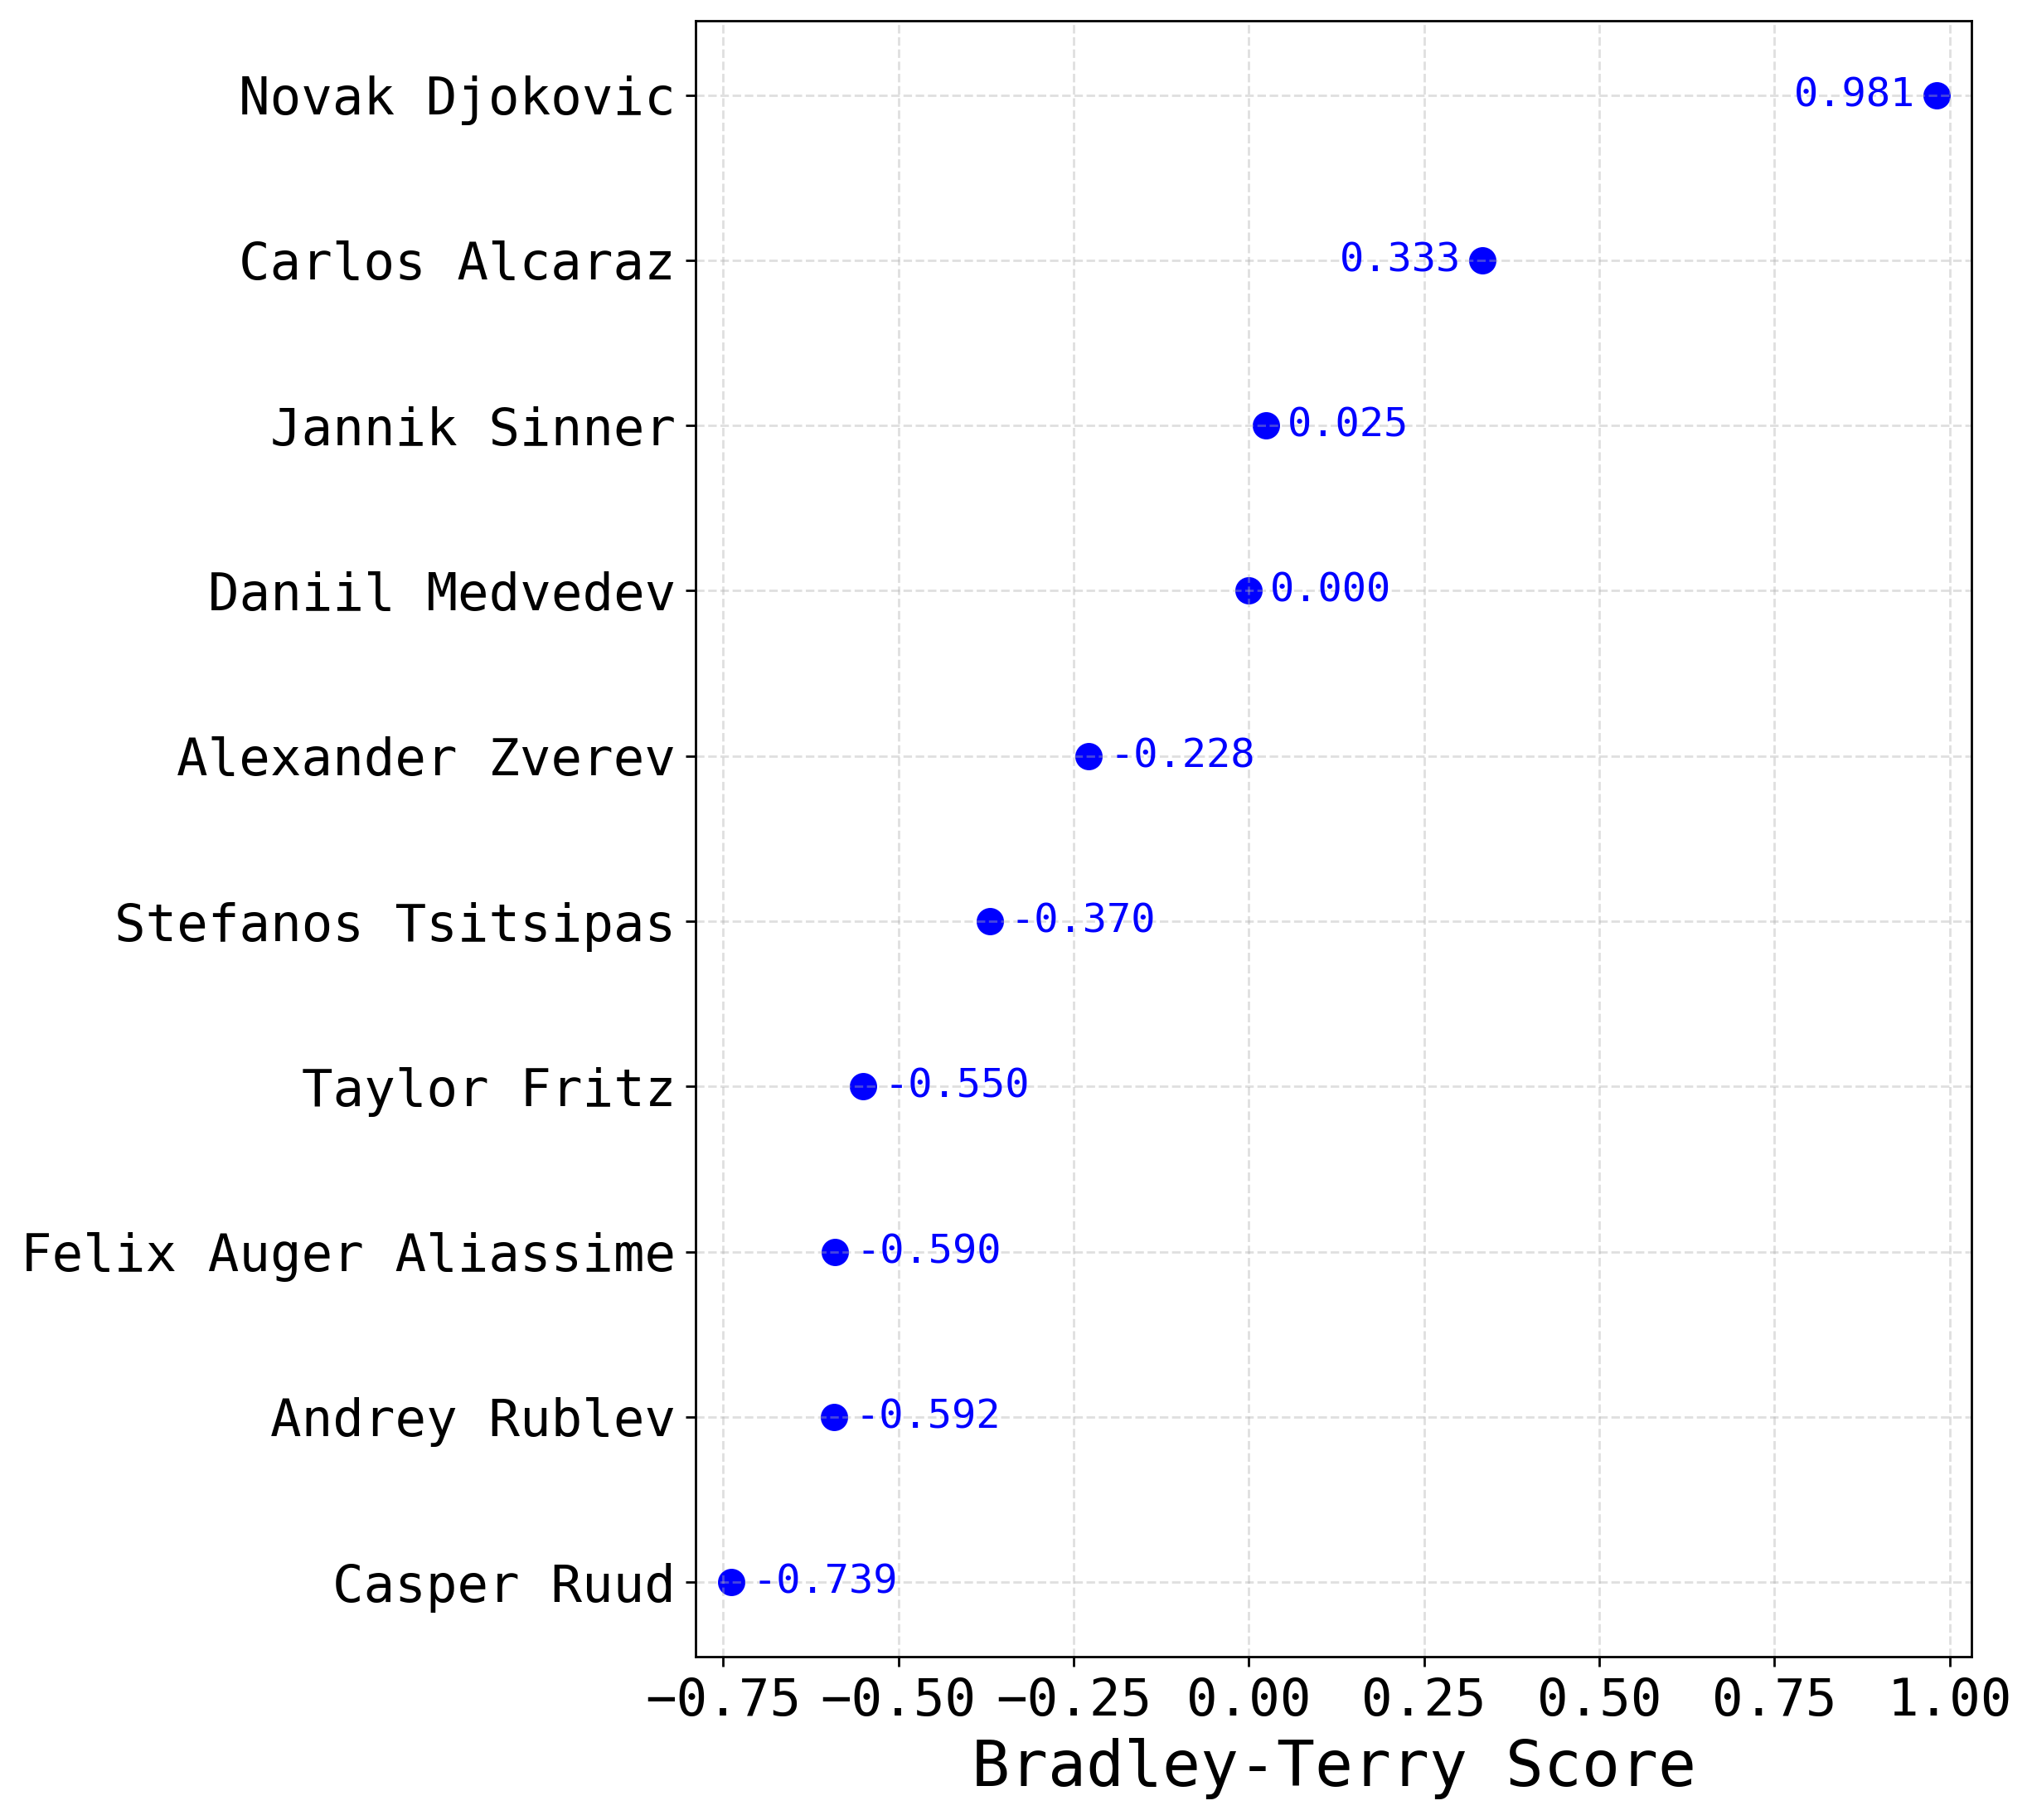

In [ ]:
# plot the rankings on the original arena
filename_to_save = 'fig/tennis3.png'
plot_title = 'Player Rankings in Tennis'
plot_bt_scores(X, y, rankings, alphaN, 10, plot_title, filename_to_save)